# DeepONet 学习积分算子（对应书中 §11.3 / Algorithm 20）

$$G(u)(x)=\int_0^x u(t)\,dt,\qquad
G_\theta(u)(x)=\sum_{k} b_k\big(u(x_1),\dots,u(x_m)\big)\,\tau_k(x)$$

In [1]:
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

In [2]:
m, p = 50, 40
xs = torch.linspace(0, 1, m)

def random_field(n, K=8):
    a = torch.randn(n, K) / torch.arange(1, K + 1)
    phase = 2 * torch.pi * torch.rand(n, K)
    def f(x):
        arg = torch.pi * torch.arange(1, K + 1) * x[None, :, None]
        return (a[:, None, :] * torch.sin(arg + phase[:, None, :])).sum(-1)
    return f

def make_data(n):
    f = random_field(n)
    u = f(xs)
    xq = torch.rand(n, 1)
    grid = torch.linspace(0, 1, 201)
    ug = f(grid)
    cum = torch.cumsum(0.5 * (ug[:, 1:] + ug[:, :-1]) * (grid[1] - grid[0]), dim=1)
    cum = torch.cat([torch.zeros(n, 1), cum], dim=1)
    idx = (xq.squeeze(1) * 200).long()
    Gu = cum.gather(1, idx[:, None])
    return u, xq, Gu

branch = nn.Sequential(nn.Linear(m, 128), nn.Tanh(), nn.Linear(128, 128), nn.Tanh(), nn.Linear(128, p))
trunk = nn.Sequential(nn.Linear(1, 128), nn.Tanh(), nn.Linear(128, 128), nn.Tanh(), nn.Linear(128, p))
bias = nn.Parameter(torch.zeros(1))

def deeponet(u, xq):
    return (branch(u) * trunk(xq)).sum(dim=1, keepdim=True) + bias

In [3]:
opt = torch.optim.Adam(list(branch.parameters()) + list(trunk.parameters()) + [bias], lr=1e-3)

for epoch in range(5001):
    u, xq, Gu = make_data(256)
    loss = ((deeponet(u, xq) - Gu) ** 2).mean()
    opt.zero_grad()
    loss.backward()
    opt.step()
    if epoch % 1000 == 0:
        print(f"epoch {epoch:5d}   loss = {loss.item():.3e}")

epoch     0   loss = 9.789e-02


epoch  1000   loss = 1.063e-03


epoch  2000   loss = 3.210e-04


epoch  3000   loss = 4.830e-04


epoch  4000   loss = 2.927e-04


epoch  5000   loss = 3.152e-04


<>:13: SyntaxWarning: invalid escape sequence '\i'
<>:13: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_671/1737757297.py:13: SyntaxWarning: invalid escape sequence '\i'
  ax.plot(grid, cum[i], "k-", label="true $\int_0^x u$")


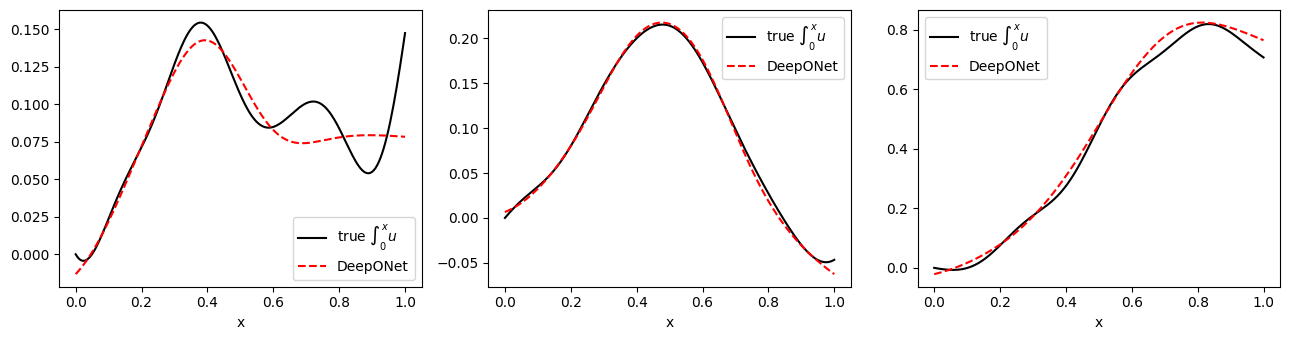

relative L2 error (3 test samples): 5.21e-02


In [4]:
f = random_field(3)
u = f(xs)
grid = torch.linspace(0, 1, 201)
ug = f(grid)
cum = torch.cumsum(0.5 * (ug[:, 1:] + ug[:, :-1]) * (grid[1] - grid[0]), dim=1)
cum = torch.cat([torch.zeros(3, 1), cum], dim=1)

with torch.no_grad():
    pred = torch.stack([deeponet(u[i:i+1].expand(201, -1), grid[:, None]).squeeze(1) for i in range(3)])

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for i, ax in enumerate(axes):
    ax.plot(grid, cum[i], "k-", label="true $\int_0^x u$")
    ax.plot(grid, pred[i], "r--", label="DeepONet")
    ax.set_xlabel("x"); ax.legend()
plt.tight_layout(); plt.show()

print(f"relative L2 error (3 test samples): {(pred - cum).norm() / cum.norm():.2e}")